## Mental Health Analysis

This project utilizes machine learning to predict the likelihood of mental health disorders based on workplace and demographic factors. By preprocessing a structured dataset, we aim to identify key predictors such as age, gender, and employer-provided mental health benefits, assessing their impact on mental health outcomes.

# Data Exploration

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns

In [5]:
data = pd.read_csv('data.csv')
data

,tech_company,benefits,workplace_resources,mh_employer_discussion,mh_coworker_discussion,medical_coverage,mental_health,mh_share,age,gender,country
0,Yes,No,I don't know,No,Yes,Yes,Possibly,5,27.0,Female,United Kingdom
1,Yes,Yes,No,No,Yes,Yes,Possibly,4,31.0,Male,United Kingdom
2,Yes,I don't know,No,Yes,Yes,No,Yes,5,36.0,Male,United States of America
3,Yes,Yes,I don't know,Yes,Yes,Yes,Yes,10,22.0,Male,United States of America
4,Yes,Yes,No,No,Yes,Yes,Yes,8,36.0,Female,United States of America
...,...,...,...,...,...,...,...,...,...,...,...
1237,No,I don't know,No,No,Yes,Yes,Yes,0,45.0,Male,United States of America
1238,No,Yes,Yes,No,No,Yes,Yes,10,30.0,Female,United States of America
1239,No,Yes,Yes,Yes,Yes,Yes,Yes,9,35.0,Male,United States of America
1240,Yes,Yes,Yes,No,No,Yes,No,10,46.0,Male,United States of America


In [8]:
data.columns

Index(['tech_company', 'benefits', 'workplace_resources',
       'mh_employer_discussion', 'mh_coworker_discussion', 'medical_coverage',
       'mental_health', 'mh_share', 'age', 'gender', 'country'],
      dtype='object')

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1242 entries, 0 to 1241
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   tech_company            1242 non-null   object 
 1   benefits                1242 non-null   object 
 2   workplace_resources     1242 non-null   object 
 3   mh_employer_discussion  1242 non-null   object 
 4   mh_coworker_discussion  1242 non-null   object 
 5   medical_coverage        1242 non-null   object 
 6   mental_health           1242 non-null   object 
 7   mh_share                1242 non-null   int64  
 8   age                     1242 non-null   float64
 9   gender                  1242 non-null   object 
 10  country                 1242 non-null   object 
dtypes: float64(1), int64(1), object(9)
memory usage: 106.9+ KB


In [12]:
data.isnull().sum()

tech_company              0
benefits                  0
workplace_resources       0
mh_employer_discussion    0
mh_coworker_discussion    0
medical_coverage          0
mental_health             0
mh_share                  0
age                       0
gender                    0
country                   0
dtype: int64

In [14]:
data.describe()

,mh_share,age
count,1242.000000,1242.000000
mean,6.572464,35.030598
std,2.701952,8.186624
min,0.000000,19.000000
25%,5.000000,29.000000
50%,7.000000,34.000000
75%,9.000000,40.000000
max,10.000000,66.000000


In [16]:
print("Train Shape:",data.shape)

Train Shape: (1242, 11)


#### Data Dictionary
**Total rows and columns**

We can see that there are 1242 rows and 12 columns in our training dataset.

   * 'Are you self-employed': 'self_employed',
   * 'Is your employer primarily a tech company/organization?': 'tech_company',
   * 'Does your employer provide mental health benefits as part of healthcare coverage?': 'benefits',
   * 'Does your employer offer resources to learn more about mental health disorders and options for seeking help?': 'workplace_resources',
   * 'Have you ever discussed your mental health with your employer?': 'mh_employer_discussion',
   * 'Have you ever discussed your mental health with coworkers?': 'mh_coworker_discussion',
   * 'Do you have medical coverage (private insurance or state-provided) that includes treatment of mental health disorders?': 'medical_coverage',
   * 'Do you currently have a mental health disorder?': 'mental_health',
   * 'How willing would you be to share with friends and family that you have a mental illness?': 'mh_share',
   * 'What is your age?': 'age',
   * 'What is your gender?': 'gender',
   * 'What country do you live in?': 'country',

In [19]:
data.describe(include='object')

,tech_company,benefits,workplace_resources,mh_employer_discussion,mh_coworker_discussion,medical_coverage,mental_health,gender,country
count,1242,1242,1242,1242,1242,1242,1242,1242,1242
unique,2,3,3,2,2,2,4,3,30
top,Yes,Yes,No,No,No,Yes,Yes,Male,United States of America
freq,899,781,465,832,679,1147,553,813,947


# Data PreProcessing

In [22]:
data['Tech_Company_Encoded'] = data['tech_company'].map({'Yes': 1, 'No': 0})
data['Employer_Mental_Health_Benefits_Encoded'] = data['benefits'].map({'Yes': 1, 'No': 0, "I don't know": np.nan})

In [24]:
Work_Environment_Impact ={'Yes': 1, 'No': 0, "I don't know": np.nan}
data['Workplace_Resources_Encoded'] = data['workplace_resources'].map(Work_Environment_Impact)

In [26]:
data['Mental_Health_Employer_Discussion_Encoded'] = data['mh_employer_discussion'].map({'Yes': 1, 'No': 0})
data['Mental_Health_Coworker_Discussion_Encoded'] = data['mh_coworker_discussion'].map({'Yes': 1, 'No': 0})
data['Medical_Coverage_Encoded'] = data['medical_coverage'].map({'Yes': 1, 'No': 0})

In [28]:
print(data['mental_health'].unique())

['Possibly' 'Yes' 'No' "Don't Know"]


In [30]:
mental_health_mapping = {'Yes': 100,'Possibly': 50, "Don't Know": np.nan, 'No': 0}
data['Mental_Health_Disorder_Encoded'] = data['mental_health'].map(mental_health_mapping)

In [32]:
data

,tech_company,benefits,workplace_resources,mh_employer_discussion,mh_coworker_discussion,medical_coverage,mental_health,mh_share,age,gender,country,Tech_Company_Encoded,Employer_Mental_Health_Benefits_Encoded,Workplace_Resources_Encoded,Mental_Health_Employer_Discussion_Encoded,Mental_Health_Coworker_Discussion_Encoded,Medical_Coverage_Encoded,Mental_Health_Disorder_Encoded
0,Yes,No,I don't know,No,Yes,Yes,Possibly,5,27.0,Female,United Kingdom,1,0.0,NaN,0,1,1,50.0
1,Yes,Yes,No,No,Yes,Yes,Possibly,4,31.0,Male,United Kingdom,1,1.0,0.0,0,1,1,50.0
2,Yes,I don't know,No,Yes,Yes,No,Yes,5,36.0,Male,United States of America,1,NaN,0.0,1,1,0,100.0
3,Yes,Yes,I don't know,Yes,Yes,Yes,Yes,10,22.0,Male,United States of America,1,1.0,NaN,1,1,1,100.0
4,Yes,Yes,No,No,Yes,Yes,Yes,8,36.0,Female,United States of America,1,1.0,0.0,0,1,1,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1237,No,I don't know,No,No,Yes,Yes,Yes,0,45.0,Male,United States of America,0,NaN,0.0,0,1,1,100.0
1238,No,Yes,Yes,No,No,Yes,Yes,10,30.0,Female,United States of America,0,1.0,1.0,0,0,1,100.0
1239,No,Yes,Yes,Yes,Yes,Yes,Yes,9,35.0,Male,United States of America,0,1.0,1.0,1,1,1,100.0
1240,Yes,Yes,Yes,No,No,Yes,No,10,46.0,Male,United States of America,1,1.0,1.0,0,0,1,0.0


In [34]:
data = pd.get_dummies(data, columns=['gender'], prefix=['Gender'], drop_first=False)

E:\Apps\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
E:\Apps\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
E:\Apps\anaconda3\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)


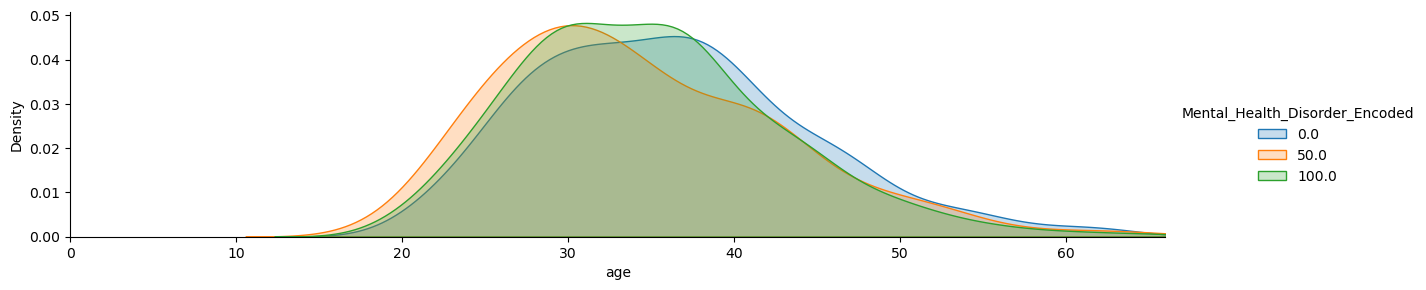

In [36]:
facet = sns.FacetGrid(data, hue="Mental_Health_Disorder_Encoded",aspect=4)
facet.map(sns.kdeplot,'age',shade= True)
facet.set(xlim=(0, data['age'].max()))
facet.add_legend() 
plt.show()

**Binning**

Binning/Converting Numerical Age to Categorical Variable

feature vector map:
* child: 0
* young: 1
* adult: 2
* mid-age: 3
* senior: 4

In [38]:
data.loc[data['age'] <= 16, 'age'] = 0  # طفل
data.loc[(data['age'] > 16) & (data['age'] <= 26), 'age'] = 1  # شاب
data.loc[(data['age'] > 26) & (data['age'] <= 36), 'age'] = 2  # بالغ
data.loc[(data['age'] > 36) & (data['age'] <= 62), 'age'] = 3  # في منتصف العمر
data.loc[data['age'] > 62, 'age'] = 4  # مسن

data['age'] = data['age'].astype(int)

In [39]:
data

,tech_company,benefits,workplace_resources,mh_employer_discussion,mh_coworker_discussion,medical_coverage,mental_health,mh_share,age,country,Tech_Company_Encoded,Employer_Mental_Health_Benefits_Encoded,Workplace_Resources_Encoded,Mental_Health_Employer_Discussion_Encoded,Mental_Health_Coworker_Discussion_Encoded,Medical_Coverage_Encoded,Mental_Health_Disorder_Encoded,Gender_Female,Gender_Male,Gender_Other
0,Yes,No,I don't know,No,Yes,Yes,Possibly,5,2,United Kingdom,1,0.0,NaN,0,1,1,50.0,True,False,False
1,Yes,Yes,No,No,Yes,Yes,Possibly,4,2,United Kingdom,1,1.0,0.0,0,1,1,50.0,False,True,False
2,Yes,I don't know,No,Yes,Yes,No,Yes,5,2,United States of America,1,NaN,0.0,1,1,0,100.0,False,True,False
3,Yes,Yes,I don't know,Yes,Yes,Yes,Yes,10,1,United States of America,1,1.0,NaN,1,1,1,100.0,False,True,False
4,Yes,Yes,No,No,Yes,Yes,Yes,8,2,United States of America,1,1.0,0.0,0,1,1,100.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1237,No,I don't know,No,No,Yes,Yes,Yes,0,3,United States of America,0,NaN,0.0,0,1,1,100.0,False,True,False
1238,No,Yes,Yes,No,No,Yes,Yes,10,2,United States of America,0,1.0,1.0,0,0,1,100.0,True,False,False
1239,No,Yes,Yes,Yes,Yes,Yes,Yes,9,2,United States of America,0,1.0,1.0,1,1,1,100.0,False,True,False
1240,Yes,Yes,Yes,No,No,Yes,No,10,3,United States of America,1,1.0,1.0,0,0,1,0.0,False,True,False


In [40]:
data.drop(['tech_company','benefits','workplace_resources','mh_employer_discussion','mh_coworker_discussion','medical_coverage','mental_health','country'], axis = 1, inplace = True)
data

,mh_share,age,Tech_Company_Encoded,Employer_Mental_Health_Benefits_Encoded,Workplace_Resources_Encoded,Mental_Health_Employer_Discussion_Encoded,Mental_Health_Coworker_Discussion_Encoded,Medical_Coverage_Encoded,Mental_Health_Disorder_Encoded,Gender_Female,Gender_Male,Gender_Other
0,5,2,1,0.0,NaN,0,1,1,50.0,True,False,False
1,4,2,1,1.0,0.0,0,1,1,50.0,False,True,False
2,5,2,1,NaN,0.0,1,1,0,100.0,False,True,False
3,10,1,1,1.0,NaN,1,1,1,100.0,False,True,False
4,8,2,1,1.0,0.0,0,1,1,100.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
1237,0,3,0,NaN,0.0,0,1,1,100.0,False,True,False
1238,10,2,0,1.0,1.0,0,0,1,100.0,True,False,False
1239,9,2,0,1.0,1.0,1,1,1,100.0,False,True,False
1240,10,3,1,1.0,1.0,0,0,1,0.0,False,True,False


In [41]:

gender_cols = [col for col in data.columns if col.startswith('Gender_')]


data[gender_cols] = data[gender_cols].astype(int)

In [42]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1242 entries, 0 to 1241
Data columns (total 12 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   mh_share                                   1242 non-null   int64  
 1   age                                        1242 non-null   int32  
 2   Tech_Company_Encoded                       1242 non-null   int64  
 3   Employer_Mental_Health_Benefits_Encoded    934 non-null    float64
 4   Workplace_Resources_Encoded                896 non-null    float64
 5   Mental_Health_Employer_Discussion_Encoded  1242 non-null   int64  
 6   Mental_Health_Coworker_Discussion_Encoded  1242 non-null   int64  
 7   Medical_Coverage_Encoded                   1242 non-null   int64  
 8   Mental_Health_Disorder_Encoded             1155 non-null   float64
 9   Gender_Female                              1242 non-null   int32  
 10  Gender_Male             

In [43]:
data

,mh_share,age,Tech_Company_Encoded,Employer_Mental_Health_Benefits_Encoded,Workplace_Resources_Encoded,Mental_Health_Employer_Discussion_Encoded,Mental_Health_Coworker_Discussion_Encoded,Medical_Coverage_Encoded,Mental_Health_Disorder_Encoded,Gender_Female,Gender_Male,Gender_Other
0,5,2,1,0.0,NaN,0,1,1,50.0,1,0,0
1,4,2,1,1.0,0.0,0,1,1,50.0,0,1,0
2,5,2,1,NaN,0.0,1,1,0,100.0,0,1,0
3,10,1,1,1.0,NaN,1,1,1,100.0,0,1,0
4,8,2,1,1.0,0.0,0,1,1,100.0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1237,0,3,0,NaN,0.0,0,1,1,100.0,0,1,0
1238,10,2,0,1.0,1.0,0,0,1,100.0,1,0,0
1239,9,2,0,1.0,1.0,1,1,1,100.0,0,1,0
1240,10,3,1,1.0,1.0,0,0,1,0.0,0,1,0


In [44]:
# data = pd.get_dummies(data, columns=['country'], prefix=['Country'], drop_first=False)

In [45]:


# country_cols = [col for col in data.columns if col.startswith('Country')]


# data[country_cols] = data[country_cols].astype(int)
# data

In [48]:
def shorten_column_names(df):
    #Shortens and improves readability of column names in a Pandas DataFrame.
    column_mapping = {
        'Gender_Female': 'Female',
        'Gender_Male': 'Male',
        'Gender_Other': 'Other',
    }
    df = df.rename(columns=column_mapping)

    return df
data = shorten_column_names(data)

# Data Visualization

In [58]:
%matplotlib inline
sns.set() # setting seaborn default for plots

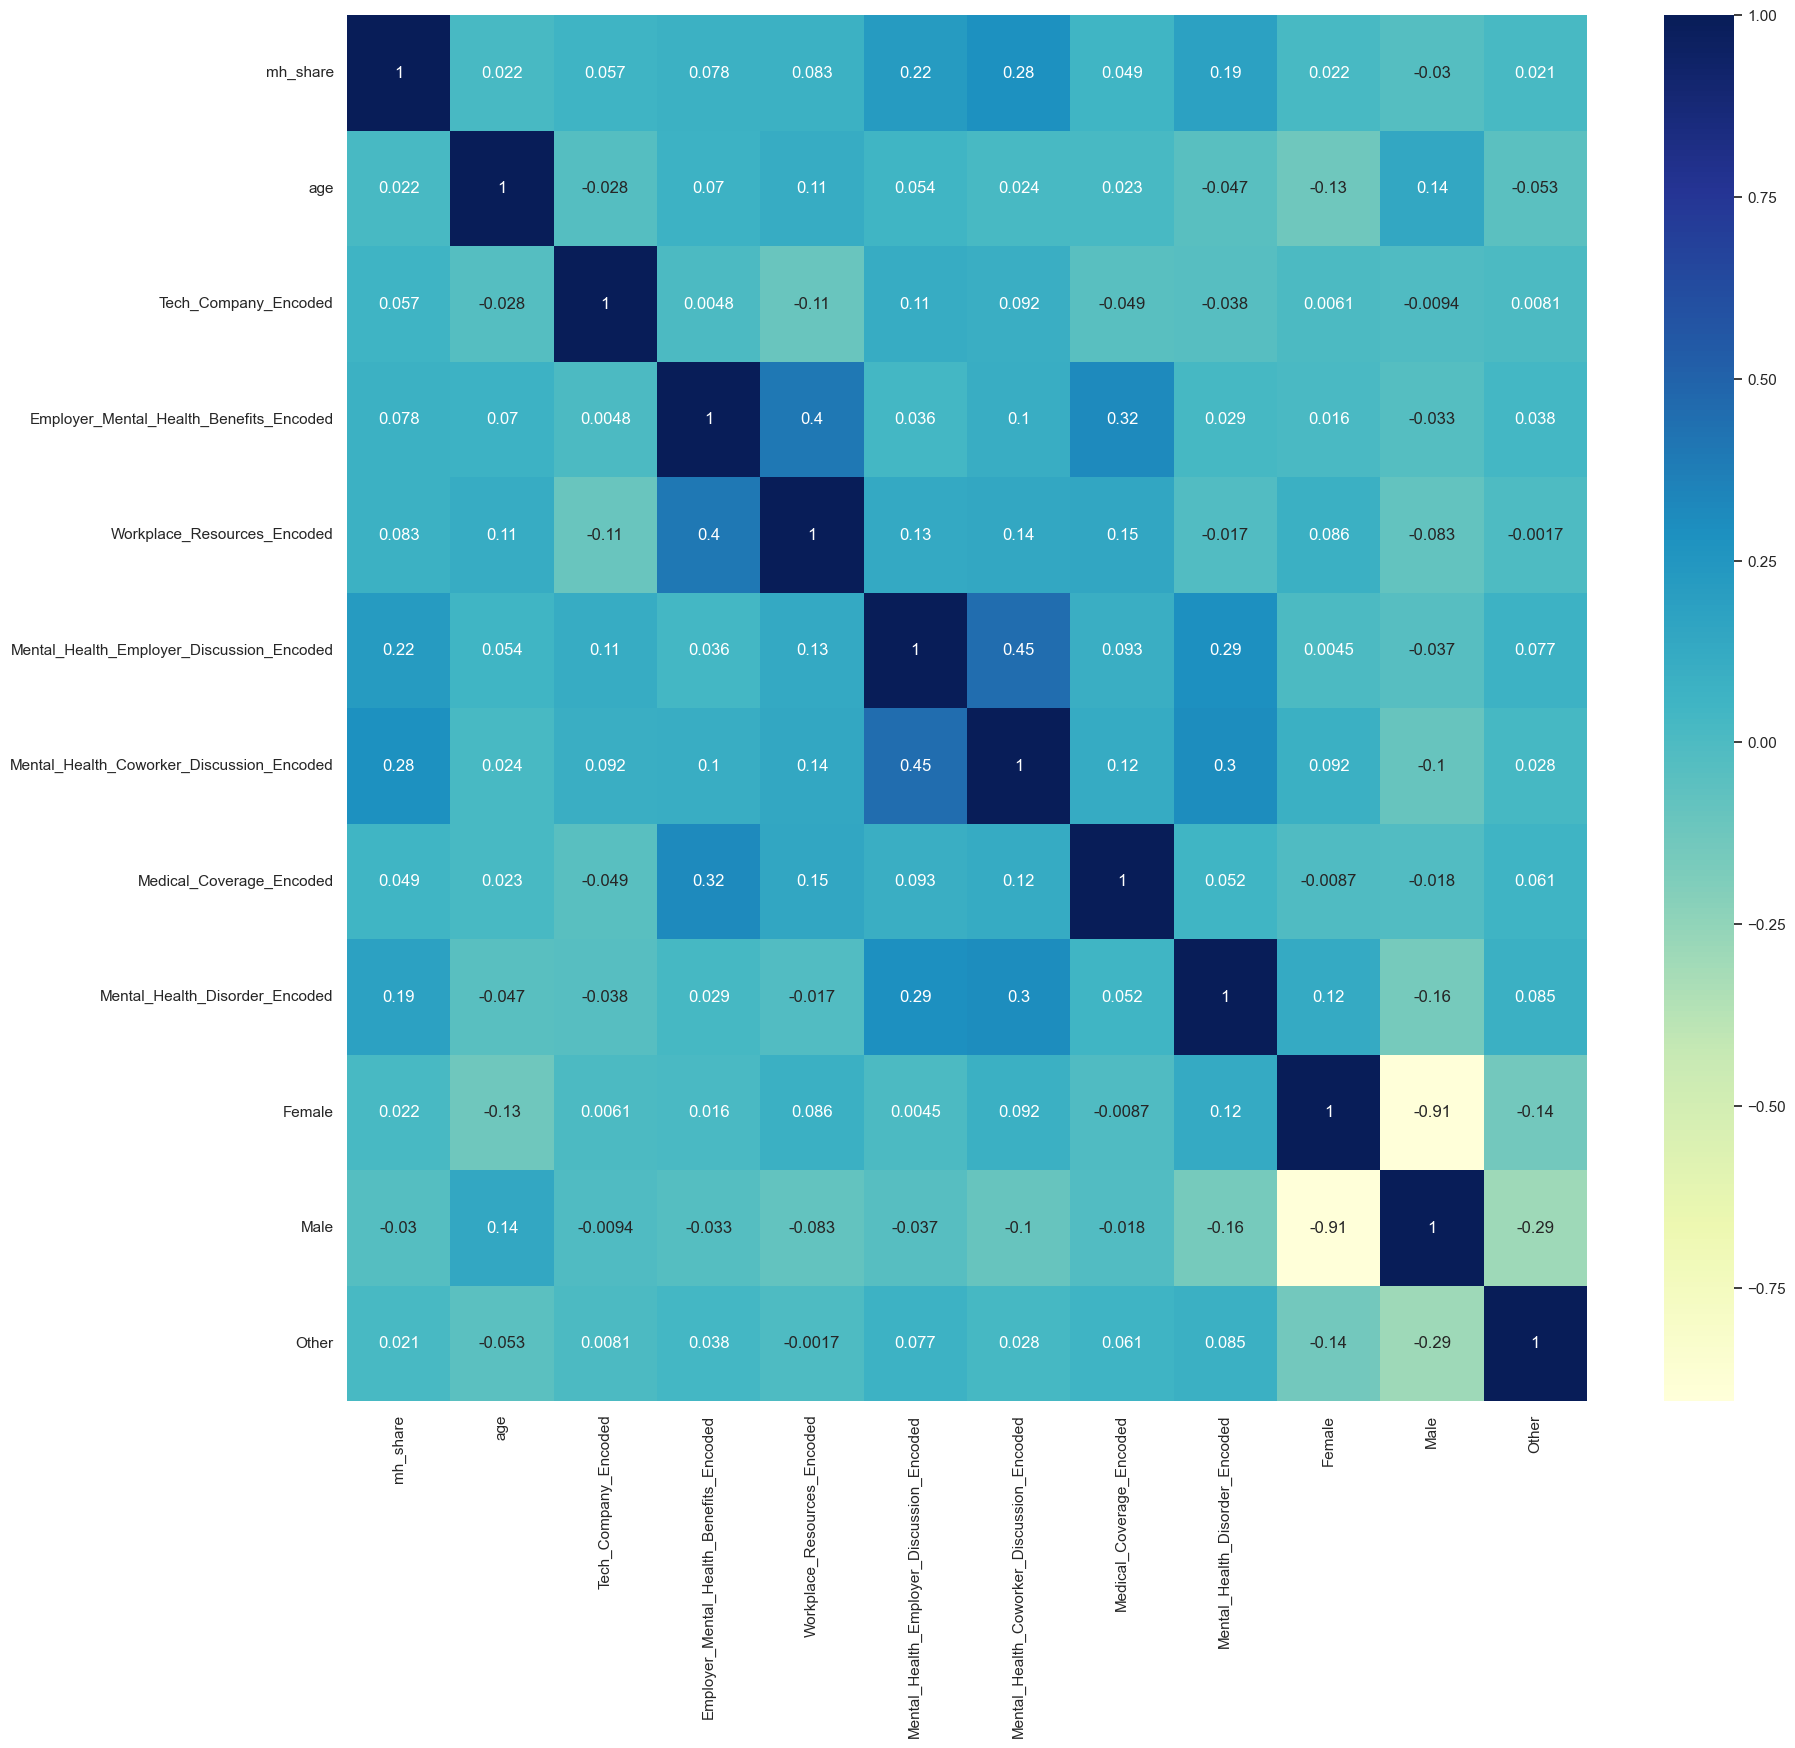

In [60]:
plt.figure(figsize=(20, 18))
sns.heatmap(data.corr(), annot = True , cmap = "YlGnBu")
plt.show()

In [61]:
print(data[data['age'] == 4])

     mh_share  age  Tech_Company_Encoded  \
16          8    4                     0   
37          5    4                     1   
821         6    4                     1   
985         5    4                     1   

     Employer_Mental_Health_Benefits_Encoded  Workplace_Resources_Encoded  \
16                                       1.0                          NaN   
37                                       NaN                          1.0   
821                                      1.0                          1.0   
985                                      1.0                          1.0   

     Mental_Health_Employer_Discussion_Encoded  \
16                                           0   
37                                           0   
821                                          1   
985                                          0   

     Mental_Health_Coworker_Discussion_Encoded  Medical_Coverage_Encoded  \
16                                           0                    

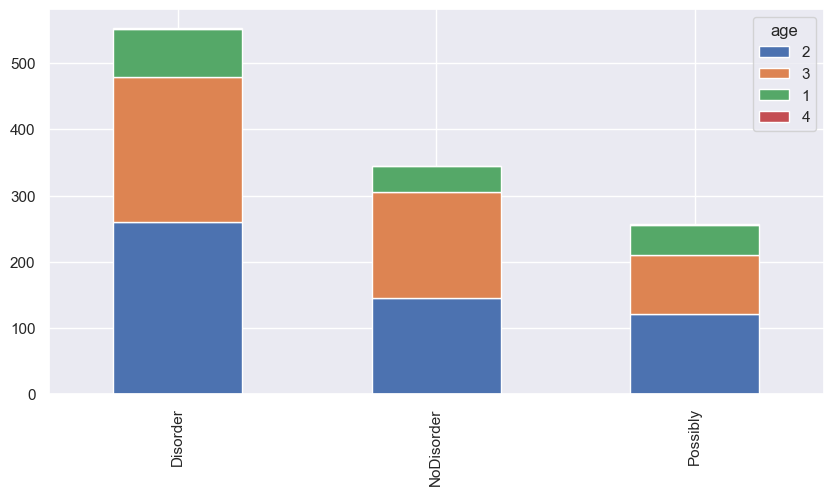

In [62]:
def bar_chart(feature):
    Disorder = data[data['Mental_Health_Disorder_Encoded']==100][feature].value_counts()
    NoDisorder = data[data['Mental_Health_Disorder_Encoded']==0][feature].value_counts()
    Possibly = data[data['Mental_Health_Disorder_Encoded']==50][feature].value_counts()
    df = pd.DataFrame([Disorder,NoDisorder,Possibly])
    df.index = ['Disorder','NoDisorder','Possibly']
    df.plot(kind='bar',stacked=True, figsize=(10,5))
bar_chart('age')

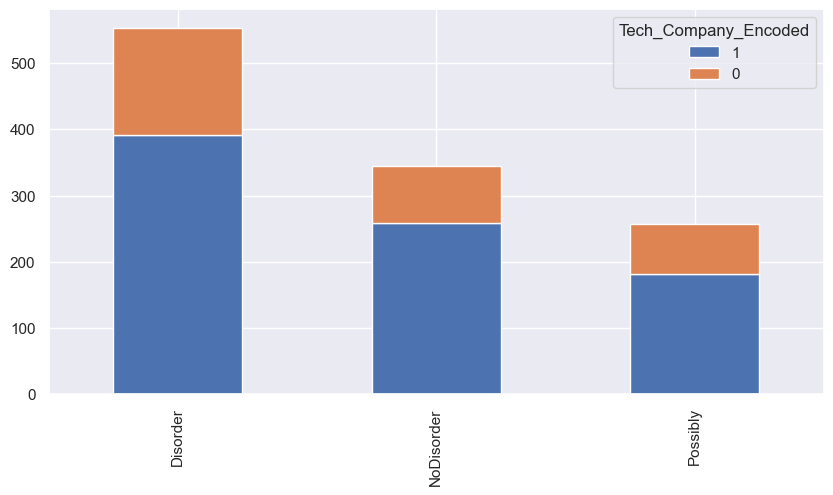

In [63]:
bar_chart('Tech_Company_Encoded')

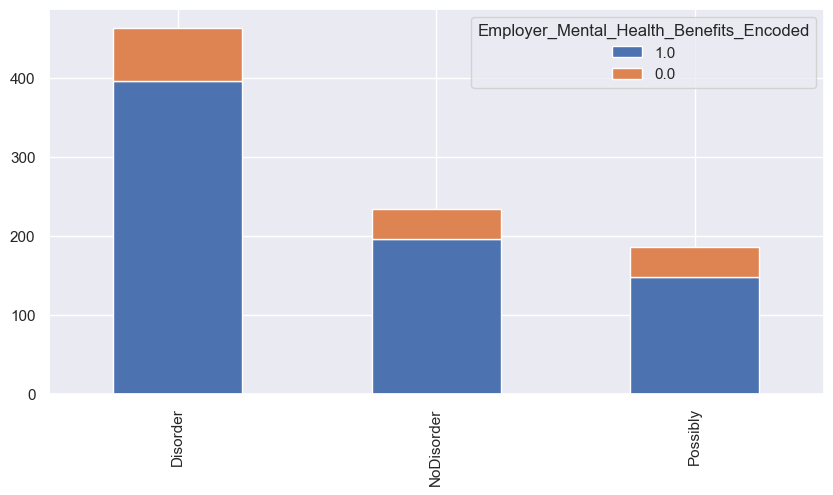

In [64]:
bar_chart('Employer_Mental_Health_Benefits_Encoded')

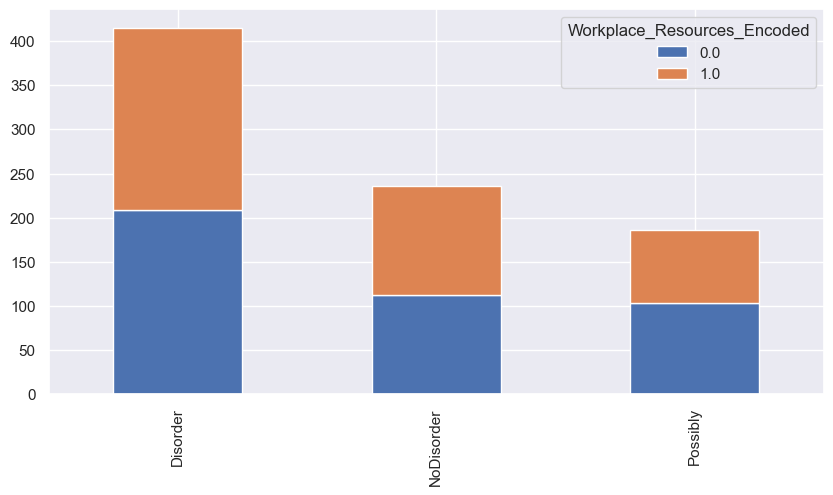

In [67]:
bar_chart('Workplace_Resources_Encoded')

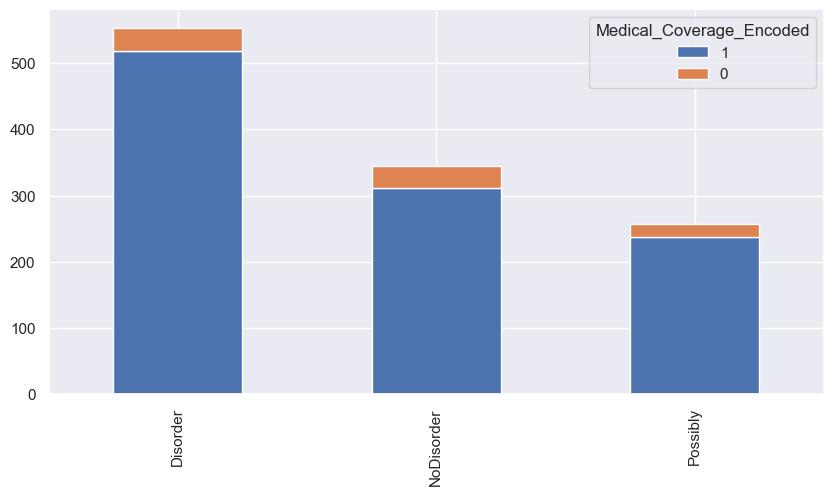

In [68]:
bar_chart('Medical_Coverage_Encoded')

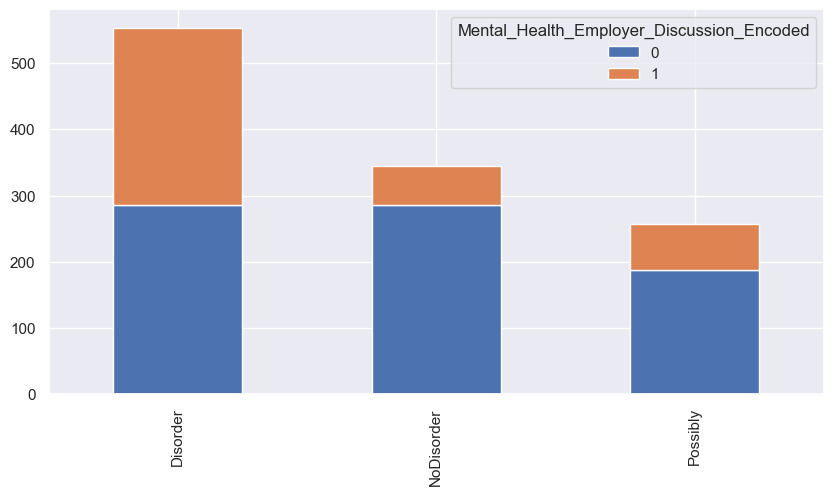

In [69]:
bar_chart('Mental_Health_Employer_Discussion_Encoded')

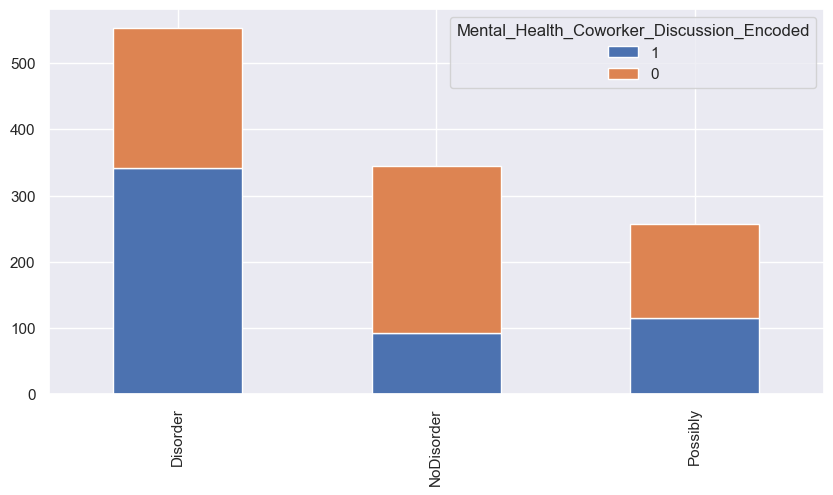

In [71]:
bar_chart('Mental_Health_Coworker_Discussion_Encoded')

# Feature Engineering

array([[<Axes: title={'center': 'mh_share'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'Tech_Company_Encoded'}>],
       [<Axes: title={'center': 'Employer_Mental_Health_Benefits_Encoded'}>,
        <Axes: title={'center': 'Workplace_Resources_Encoded'}>,
        <Axes: title={'center': 'Mental_Health_Employer_Discussion_Encoded'}>],
       [<Axes: title={'center': 'Mental_Health_Coworker_Discussion_Encoded'}>,
        <Axes: title={'center': 'Medical_Coverage_Encoded'}>,
        <Axes: title={'center': 'Mental_Health_Disorder_Encoded'}>],
       [<Axes: title={'center': 'Female'}>,
        <Axes: title={'center': 'Male'}>,
        <Axes: title={'center': 'Other'}>]], dtype=object)

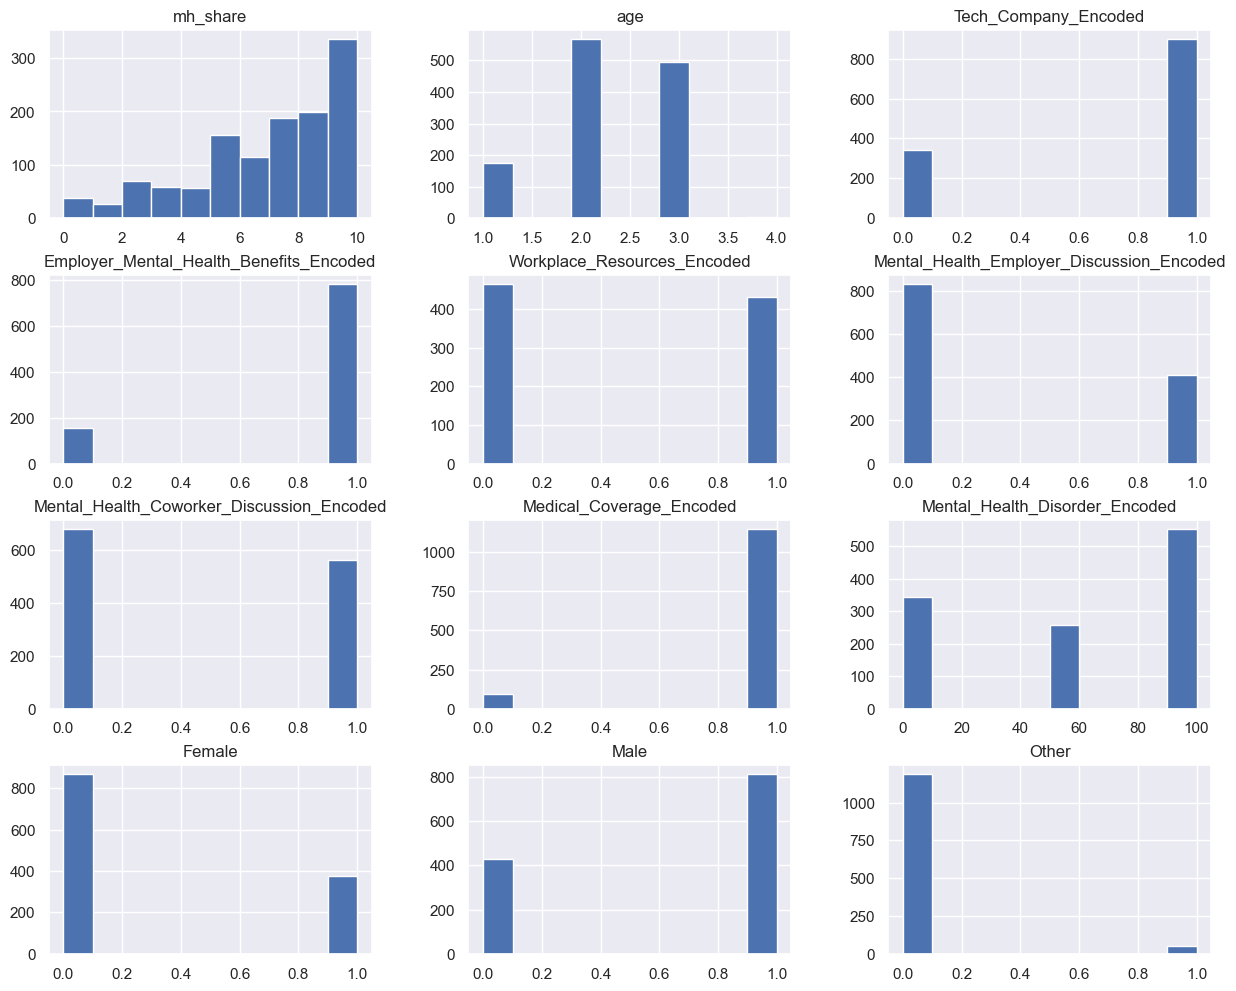

In [74]:
data.hist(figsize = (15,12))

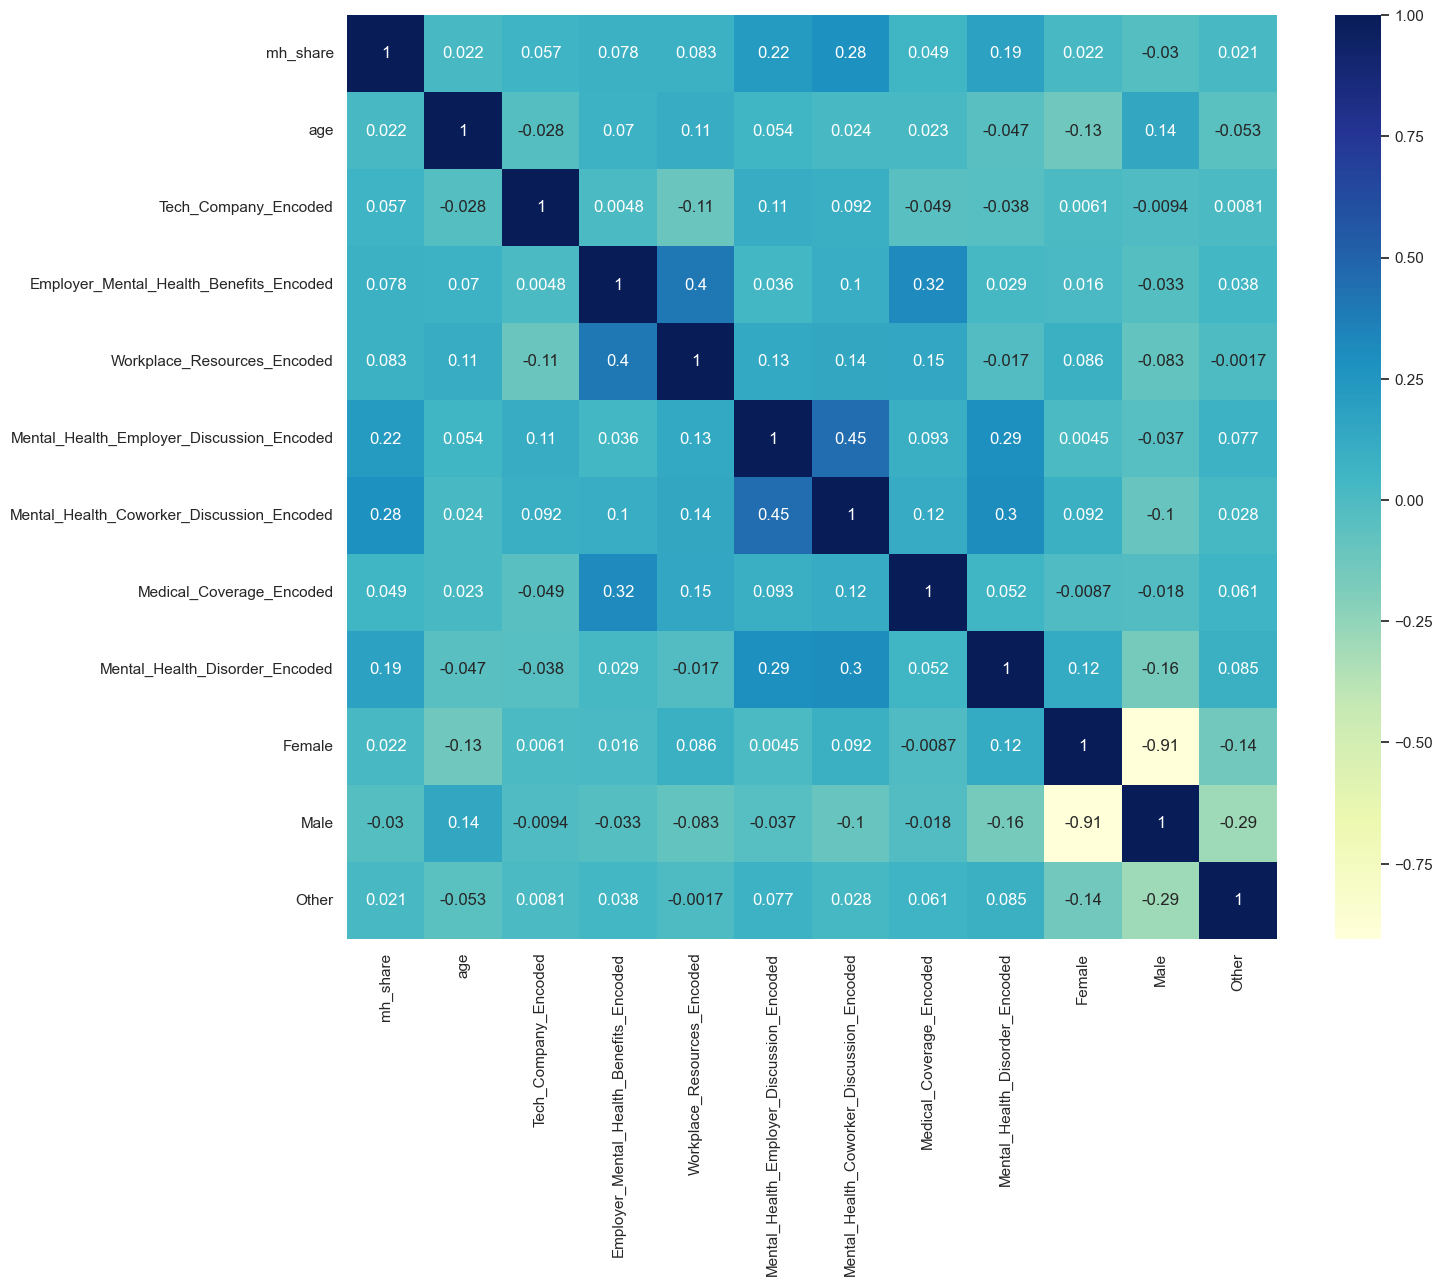

In [76]:
plt.figure(figsize=(15, 12))
sns.heatmap(data.corr(), annot = True , cmap = "YlGnBu")
plt.show()

In [78]:
data = data.dropna()

In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 683 entries, 1 to 1241
Data columns (total 12 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   mh_share                                   683 non-null    int64  
 1   age                                        683 non-null    int32  
 2   Tech_Company_Encoded                       683 non-null    int64  
 3   Employer_Mental_Health_Benefits_Encoded    683 non-null    float64
 4   Workplace_Resources_Encoded                683 non-null    float64
 5   Mental_Health_Employer_Discussion_Encoded  683 non-null    int64  
 6   Mental_Health_Coworker_Discussion_Encoded  683 non-null    int64  
 7   Medical_Coverage_Encoded                   683 non-null    int64  
 8   Mental_Health_Disorder_Encoded             683 non-null    float64
 9   Female                                     683 non-null    int32  
 10  Male                          

In [82]:
data.corr()

,mh_share,age,Tech_Company_Encoded,Employer_Mental_Health_Benefits_Encoded,Workplace_Resources_Encoded,Mental_Health_Employer_Discussion_Encoded,Mental_Health_Coworker_Discussion_Encoded,Medical_Coverage_Encoded,Mental_Health_Disorder_Encoded,Female,Male,Other
mh_share,1.000000,0.010369,0.069450,0.090118,0.081598,0.204340,0.281368,0.049578,0.204488,-0.012463,-0.011603,0.049943
age,0.010369,1.000000,-0.041878,0.062916,0.116229,0.054198,0.037786,0.014429,-0.056787,-0.161440,0.188374,-0.067568
Tech_Company_Encoded,0.069450,-0.041878,1.000000,-0.017868,-0.095405,0.140341,0.099554,-0.074101,0.023103,0.006030,-0.021394,0.032816
Employer_Mental_Health_Benefits_Encoded,0.090118,0.062916,-0.017868,1.000000,0.402612,0.035331,0.114899,0.329589,0.029456,0.073062,-0.084099,0.028149
Workplace_Resources_Encoded,0.081598,0.116229,-0.095405,0.402612,1.000000,0.130023,0.112167,0.128569,-0.031813,0.054017,-0.041393,-0.023037
Mental_Health_Employer_Discussion_Encoded,0.204340,0.054198,0.140341,0.035331,0.130023,1.000000,0.458733,0.024645,0.284865,-0.015944,-0.013947,0.062002
Mental_Health_Coworker_Discussion_Encoded,0.281368,0.037786,0.099554,0.114899,0.112167,0.458733,1.000000,0.043527,0.290700,0.062603,-0.077195,0.034951
Medical_Coverage_Encoded,0.049578,0.014429,-0.074101,0.329589,0.128569,0.024645,0.043527,1.000000,0.020823,0.002468,-0.019869,0.036876
Mental_Health_Disorder_Encoded,0.204488,-0.056787,0.023103,0.029456,-0.031813,0.284865,0.290700,0.020823,1.000000,0.120680,-0.163094,0.097513
Female,-0.012463,-0.161440,0.006030,0.073062,0.054017,-0.015944,0.062603,0.002468,0.120680,1.000000,-0.884521,-0.177077


In [206]:
data['Mental_Health_Disorder_Encoded'].value_counts()

Mental_Health_Disorder_Encoded
100.0    356
0.0      184
50.0     143
Name: count, dtype: int64

#   Modelling

In [91]:
# Importing Classifier Modules
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier,ExtraTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier,BaggingClassifier,AdaBoostClassifier,GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

In [92]:
x = data.drop('Mental_Health_Disorder_Encoded', axis=1)
y = data['Mental_Health_Disorder_Encoded']

In [93]:
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Logistic Regression

In [208]:
model = LogisticRegression(max_iter=4000,C=10,solver='liblinear',class_weight='balanced')

In [210]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga']
}
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='accuracy', cv=5)

grid_search.fit(X_train, y_train)

print(f'Best Hyperparameters: {grid_search.best_params_}')

Best Hyperparameters: {'C': 1, 'solver': 'liblinear'}


Accuracy Logistic Regression: 0.613


Text(0.5, 1.05, 'Confusion_matrix')

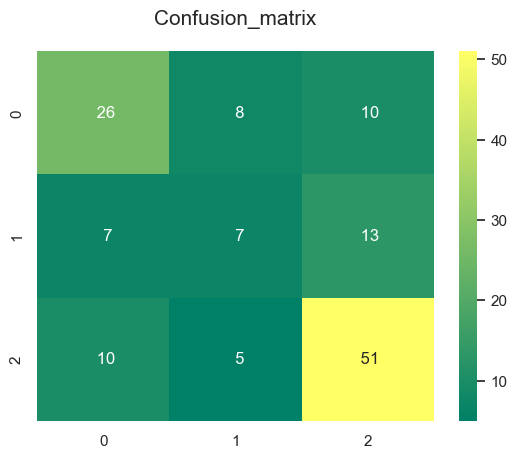

In [212]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy Logistic Regression: {accuracy:.3f}')
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='3.0f',cmap="summer")
plt.title('Confusion_matrix', y=1.05, size=15)

In [214]:
print('Accuracy: {:.3f}'.format(accuracy_score(y_test, y_pred)))
print('Precision: {:.3f}'.format(precision_score(y_test, y_pred,average='weighted')))
print('Recall: {:.3f}'.format(recall_score(y_test, y_pred,average='weighted')))
print('F1 Score: {:.3f}'.format(f1_score(y_test, y_pred,average='weighted')))

Accuracy: 0.613
Precision: 0.595
Recall: 0.613
F1 Score: 0.602


In [216]:
class_report = classification_report(y_test, y_pred)
print('Classification Report:')
print(class_report)

Classification Report:
              precision    recall  f1-score   support

         0.0       0.60      0.59      0.60        44
        50.0       0.35      0.26      0.30        27
       100.0       0.69      0.77      0.73        66

    accuracy                           0.61       137
   macro avg       0.55      0.54      0.54       137
weighted avg       0.60      0.61      0.60       137



# DecisionTreeClassifier

In [223]:
# {'criterion': 'entropy', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10}

tree_model = DecisionTreeClassifier(criterion='entropy',max_depth=5,max_features='sqrt',min_samples_leaf=4,min_samples_split=10,random_state=39,)
tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)


print("Decision Tree")
print(f'Accuracy: {accuracy_score(y_test, y_pred_tree):.2f}')
print('Precision: {:.3f}'.format(precision_score(y_test, y_pred_tree,average='weighted')))
print('Recall: {:.3f}'.format(recall_score(y_test, y_pred_tree,average='weighted')))
print('F1 Score: {:.3f}'.format(f1_score(y_test, y_pred_tree,average='weighted')))
print('Classification Report:')
print(classification_report(y_test, y_pred_tree))

Decision Tree
Accuracy: 0.57
Precision: 0.460
Recall: 0.569
F1 Score: 0.509
Classification Report:
              precision    recall  f1-score   support

         0.0       0.51      0.61      0.56        44
        50.0       0.00      0.00      0.00        27
       100.0       0.61      0.77      0.68        66

    accuracy                           0.57       137
   macro avg       0.37      0.46      0.41       137
weighted avg       0.46      0.57      0.51       137



### Improve DecisionTree

In [226]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

tree_model = DecisionTreeClassifier(random_state=42)

param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(estimator=tree_model, param_grid=param_grid, scoring='f1_weighted', cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)


Best Parameters:
{'criterion': 'entropy', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10}


Accuracy DecisionTree: 0.474


Text(0.5, 1.05, 'Confusion_matrix')

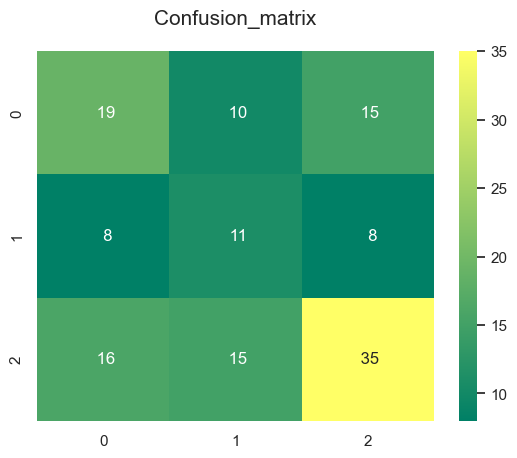

In [227]:
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_tree)
print(f'Accuracy DecisionTree: {accuracy:.3f}')
sns.heatmap(confusion_matrix(y_test,y_pred_tree),annot=True,fmt='3.0f',cmap="summer")
plt.title('Confusion_matrix', y=1.05, size=15)

# RandomForest

In [248]:
from sklearn.ensemble import RandomForestClassifier

# Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
rf_model = RandomForestClassifier(n_estimators=100,max_depth=10,max_features='sqrt',min_samples_leaf=1,min_samples_split=5,class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


print(f'Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}')
print('Precision: {:.3f}'.format(precision_score(y_test, y_pred_rf,average='weighted')))
print('Recall: {:.3f}'.format(recall_score(y_test, y_pred_rf,average='weighted')))
print('F1 Score: {:.3f}'.format(f1_score(y_test, y_pred_rf,average='weighted')))
print('Classification Report:')
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.518
Precision: 0.511
Recall: 0.518
F1 Score: 0.514
Classification Report:
              precision    recall  f1-score   support

         0.0       0.49      0.52      0.51        44
        50.0       0.26      0.22      0.24        27
       100.0       0.63      0.64      0.63        66

    accuracy                           0.52       137
   macro avg       0.46      0.46      0.46       137
weighted avg       0.51      0.52      0.51       137



In [118]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

rf_model = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 250, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, scoring='f1_weighted', cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

best_rf_model = grid_search.best_estimator_

print(f'Best Parameters: {grid_search.best_params_}')

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


E:\Apps\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:547: FitFailedWarning: 
720 fits failed out of a total of 2160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
246 fits failed with the following error:
Traceback (most recent call last):
  File "E:\Apps\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 895, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "E:\Apps\anaconda3\Lib\site-packages\sklearn\base.py", line 1467, in wrapper
    estimator._validate_params()
  File "E:\Apps\anaconda3\Lib\site-packages\sklearn\base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "E:\Apps\anaconda3\Lib\site-packages\sklearn\utils\_param_validation

## Confusion_matrix

Accuracy: 0.533


Text(0.5, 1.05, 'Confusion_matrix')

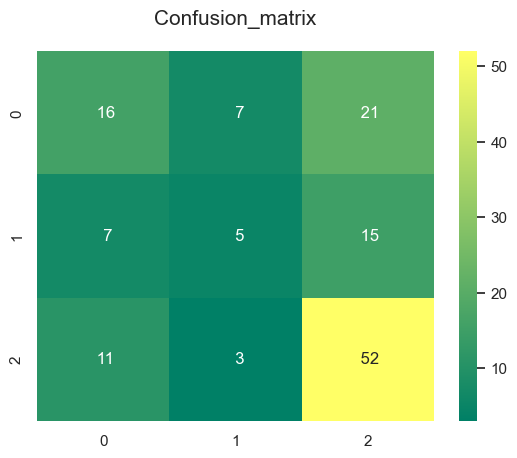

In [120]:
best_rf_model.fit(X_train, y_train)
y_pred = best_rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.3f}')
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='3.0f',cmap="summer")
plt.title('Confusion_matrix', y=1.05, size=15)

## AdaBoostClassifier

In [252]:
from sklearn.ensemble import AdaBoostClassifier


ada_model = AdaBoostClassifier(n_estimators=200)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)


print(f'Accuracy: {accuracy_score(y_test, y_pred_ada):.2f}')
print('Precision: {:.3f}'.format(precision_score(y_test, y_pred_ada,average='weighted')))
print('Recall: {:.3f}'.format(recall_score(y_test, y_pred_ada,average='weighted')))
print('F1 Score: {:.3f}'.format(f1_score(y_test, y_pred_ada,average='weighted')))
print('Classification Report:')
print(classification_report(y_test, y_pred_ada))

E:\Apps\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy: 0.57
Precision: 0.538
Recall: 0.569
F1 Score: 0.539
Classification Report:
              precision    recall  f1-score   support

         0.0       0.59      0.45      0.51        44
        50.0       0.29      0.15      0.20        27
       100.0       0.61      0.82      0.70        66

    accuracy                           0.57       137
   macro avg       0.49      0.47      0.47       137
weighted avg       0.54      0.57      0.54       137



In [123]:
AdaBoostClassifier?

Init signature:
AdaBoostClassifier(
    estimator=None,
    *,
    n_estimators=50,
    learning_rate=1.0,
    algorithm='SAMME.R',
    random_state=None,
)
Docstring:     
An AdaBoost classifier.

An AdaBoost [1]_ classifier is a meta-estimator that begins by fitting a
classifier on the original dataset and then fits additional copies of the
classifier on the same dataset but where the weights of incorrectly
classified instances are adjusted such that subsequent classifiers focus
more on difficult cases.

This class implements the algorithm based on [2]_.

Read more in the :ref:`User Guide <adaboost>`.

.. versionadded:: 0.14

Parameters
----------
estimator : object, default=None
    The base estimator from which the boosted ensemble is built.
    Support for sample weighting is required, as well as proper
    ``classes_`` and ``n_classes_`` attributes. If ``None``, then
    the base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`
    initialized with `max_depth=1`.

    .

###  n_estimators=100,


In [125]:
from sklearn.ensemble import AdaBoostClassifier


ada_model = AdaBoostClassifier(n_estimators=100)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)


print(f'Accuracy: {accuracy_score(y_test, y_pred_ada):.2f}')
print('Precision: {:.3f}'.format(precision_score(y_test, y_pred_ada,average='weighted')))
print('Recall: {:.3f}'.format(recall_score(y_test, y_pred_ada,average='weighted')))
print('F1 Score: {:.3f}'.format(f1_score(y_test, y_pred_ada,average='weighted')))
print('Classification Report:')
print(classification_report(y_test, y_pred_ada))

Accuracy: 0.57
Precision: 0.538
Recall: 0.569
F1 Score: 0.539
Classification Report:
              precision    recall  f1-score   support

         0.0       0.59      0.45      0.51        44
        50.0       0.29      0.15      0.20        27
       100.0       0.61      0.82      0.70        66

    accuracy                           0.57       137
   macro avg       0.49      0.47      0.47       137
weighted avg       0.54      0.57      0.54       137



E:\Apps\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


## Confusion_matrix

E:\Apps\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Accuracy : 0.569


Text(0.5, 1.05, 'Confusion_matrix')

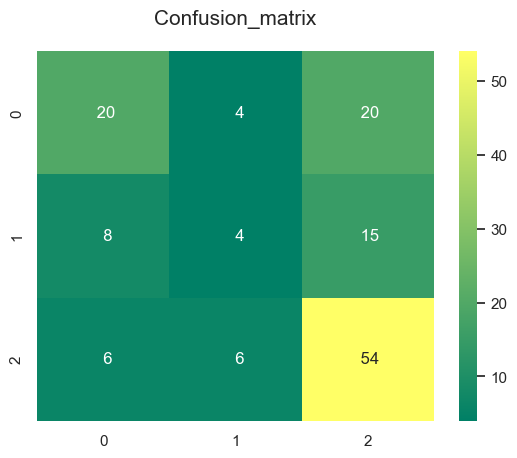

In [127]:
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_ada)
print(f'Accuracy : {accuracy:.3f}')
sns.heatmap(confusion_matrix(y_test,y_pred_ada),annot=True,fmt='3.0f',cmap="summer")
plt.title('Confusion_matrix', y=1.05, size=15)

# KNeighbors

In [129]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors = 13)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=13)

In [254]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


param_grid = {'n_neighbors': range(1, 30), 'weights': ['uniform', 'distance']}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)


best_params = grid_search.best_params_
print(f"Best parameters: {best_params}")


model = KNeighborsClassifier(n_neighbors=best_params['n_neighbors'], weights=best_params['weights'])
model.fit(X_train_scaled, y_train)


y_pred_k = model.predict(X_test_scaled)


print('Accuracy: {:.3f}'.format(accuracy_score(y_test, y_pred_k)))
print('Precision: {:.3f}'.format(precision_score(y_test, y_pred_k, average='weighted')))
print('Recall: {:.3f}'.format(recall_score(y_test, y_pred_k, average='weighted')))
print('F1 Score: {:.3f}'.format(f1_score(y_test, y_pred_k, average='weighted')))


class_report = classification_report(y_test, y_pred_k)
print('Classification Report:')
print(class_report)


Best parameters: {'n_neighbors': 20, 'weights': 'uniform'}
Accuracy: 0.562
Precision: 0.518
Recall: 0.562
F1 Score: 0.517
Classification Report:
              precision    recall  f1-score   support

         0.0       0.48      0.48      0.48        44
        50.0       0.33      0.07      0.12        27
       100.0       0.62      0.82      0.71        66

    accuracy                           0.56       137
   macro avg       0.48      0.46      0.43       137
weighted avg       0.52      0.56      0.52       137



## Confusion_matrix

Accuracy : 0.562


Text(0.5, 1.05, 'Confusion_matrix')

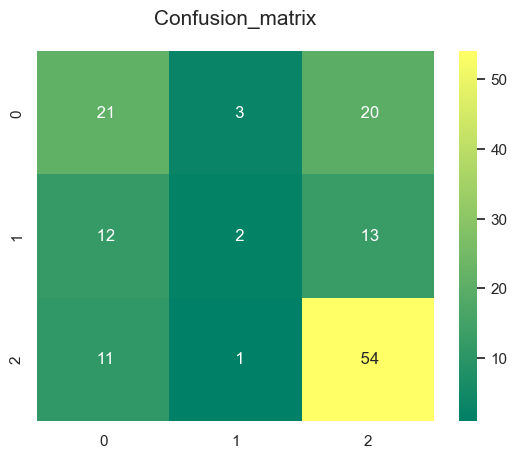

In [132]:
model.fit(X_train, y_train)
y_pred_k = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_k)
print(f'Accuracy : {accuracy:.3f}')
sns.heatmap(confusion_matrix(y_test,y_pred_k),annot=True,fmt='3.0f',cmap="summer")
plt.title('Confusion_matrix', y=1.05, size=15)

## Neural Networks


In [152]:
from sklearn.neural_network import MLPClassifier
param_grid = {
    'hidden_layer_sizes': [(100,), (128, 64), (64, 32, 16)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam', 'sgd'],
    'learning_rate_init': [0.01, 0.001, 0.0001]
}

grid_search = GridSearchCV(MLPClassifier(max_iter=10000), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)


Best Parameters: {'activation': 'tanh', 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.0001, 'solver': 'adam'}


In [258]:
nn_model = MLPClassifier(max_iter=1000,activation='relu',solver='sgd',learning_rate_init=0.001,hidden_layer_sizes=(128, 64),random_state=71)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)


print('Accuracy: {:.2f}'.format(accuracy_score(y_test, y_pred_nn)))
print('Precision: {:.2f}'.format(precision_score(y_test, y_pred_nn,average='weighted')))
print('Recall: {:.2f}'.format(recall_score(y_test, y_pred_nn,average='weighted')))
print('F1: {:.2f}'.format(f1_score(y_test, y_pred_nn,average='weighted')))

print('Classification Report:')
print(classification_report(y_test, y_pred_nn))

Accuracy: 0.57
Precision: 0.55
Recall: 0.57
F1: 0.55
Classification Report:
              precision    recall  f1-score   support

         0.0       0.53      0.45      0.49        44
        50.0       0.39      0.26      0.31        27
       100.0       0.63      0.77      0.69        66

    accuracy                           0.57       137
   macro avg       0.51      0.50      0.50       137
weighted avg       0.55      0.57      0.55       137



E:\Apps\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


## Confusion_matrix

Accuracy : 0.540


E:\Apps\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Text(0.5, 1.05, 'Confusion_matrix')

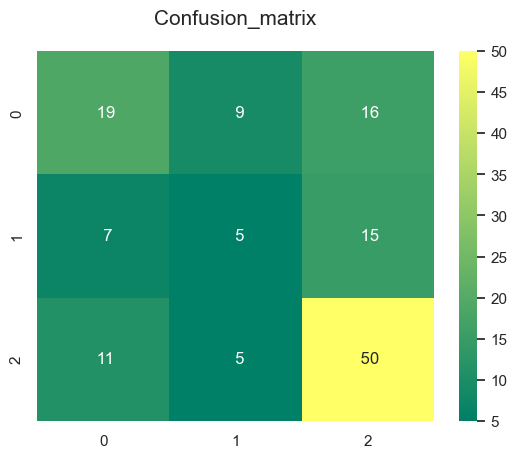

In [137]:
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_nn)
print(f'Accuracy : {accuracy:.3f}')
sns.heatmap(confusion_matrix(y_test,y_pred_nn),annot=True,fmt='3.0f',cmap="summer")
plt.title('Confusion_matrix', y=1.05, size=15)

### Save Model

In [141]:
import joblib

joblib.dump(nn_model, 'best_model.pkl')
print("The best model has been saved successfully!")


The best model has been saved successfully!


In [142]:
model = joblib.load('best_model.pkl')

In [143]:
data

,mh_share,age,Tech_Company_Encoded,Employer_Mental_Health_Benefits_Encoded,Workplace_Resources_Encoded,Mental_Health_Employer_Discussion_Encoded,Mental_Health_Coworker_Discussion_Encoded,Medical_Coverage_Encoded,Mental_Health_Disorder_Encoded,Female,Male,Other
1,4,2,1,1.0,0.0,0,1,1,50.0,0,1,0
4,8,2,1,1.0,0.0,0,1,1,100.0,1,0,0
5,3,3,1,1.0,0.0,0,0,1,0.0,1,0,0
6,2,3,0,1.0,0.0,1,1,1,100.0,0,1,0
12,3,1,1,0.0,0.0,0,0,1,50.0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1235,2,2,1,1.0,1.0,0,0,1,0.0,0,1,0
1238,10,2,0,1.0,1.0,0,0,1,100.0,1,0,0
1239,9,2,0,1.0,1.0,1,1,1,100.0,0,1,0
1240,10,3,1,1.0,1.0,0,0,1,0.0,0,1,0


In [194]:
feature_names = [
    'mh_share', 'age', 'Tech_Company_Encoded', 'Employer_Mental_Health_Benefits_Encoded',
    'Workplace_Resources_Encoded', 'Mental_Health_Employer_Discussion_Encoded',
    'Mental_Health_Coworker_Discussion_Encoded', 'Medical_Coverage_Encoded',
    'Female', 'Male', 'Other'
]

new_data = np.array([[4, 3, 1, 0, 0, 1, 1, 1, 1, 0, 0]])
new_data_df = pd.DataFrame(new_data, columns=feature_names)

In [196]:
prediction = model.predict(new_data_df)

if prediction[0] == 100:
    print("The person has a mental disorder")
elif prediction[0] == 0:
    print("The person does not have a mental disorder")
else:
    print("The person may possibly have a mental disorder")


The person has a mental disorder


E:\Apps\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but MLPClassifier was fitted without feature names
  warnings.warn(


In [202]:
X_test

array([[ 0.45381272, -0.40535803,  0.64666979, ..., -0.75131213,
         0.85314014, -0.25362864],
       [-1.04335795, -0.40535803,  0.64666979, ...,  1.33100473,
        -1.17214037, -0.25362864],
       [-0.29477261, -0.40535803, -1.54638428, ..., -0.75131213,
        -1.17214037,  3.94277244],
       ...,
       [-1.41765062,  1.07014521,  0.64666979, ..., -0.75131213,
         0.85314014, -0.25362864],
       [ 0.82810539,  1.07014521,  0.64666979, ..., -0.75131213,
         0.85314014, -0.25362864],
       [-0.29477261,  1.07014521,  0.64666979, ..., -0.75131213,
         0.85314014, -0.25362864]])

In [200]:
y_test

553     100.0
290     100.0
405     100.0
238     100.0
575       0.0
        ...  
222     100.0
167       0.0
106      50.0
404     100.0
1025    100.0
Name: Mental_Health_Disorder_Encoded, Length: 137, dtype: float64